### ASTR 3300/5300: Astrostatistics
***N. Pol***
___

# Homework 3
### Due: Wednesday, Sep. 30 at 11.59pm CST
---

## Only one problem this week

This problem uses a dataset in `/coursework/homeworks/hw_data/`.

1) Read in `hw3_data_1.npy`. This is a (50 x 2) numpy array, with measurements in the first column and uncertainties in the second column. Using the analytic results for heteroscedastic Gaussian data from lectures, compute the sample mean and the standard error on the sample mean from for this data.

2) Reusing some approaches and tools from `Lecture_6`, write a ln-likelihood function for heteroscedastic Gaussian data, and use it in a fitting algorithm to find the best-fit mean. *Remember that scipy optimizers are set up to minimize functions.*

3) Using the same numerical technique from `Lecture_5`, compute the Fisher uncertainty estimate on the mean.

4) Using the bootstrap method, generate $1000$ bootstrap realizations of this dataset. *DO NOT use the `astroML` code. Write your own bootstrap function from scratch. Also recall that when resampling data, measurements and uncertainties should stay paired together.*

5) Repeat (2) with all $1000$ boostrap datasets to find the distribution of the sample mean. Plot a normalized histogram of these bootstrap means, and overplot a Gaussian pdf with the mean and std found in (1). Do these agree?

6) While we have fitted a heteroscedastic Gaussian to this data, let's try something else. Write some code to define a ln-likelihood for a Laplace distribution evaluated on this data. Fit simultaneously for the Laplace location parameter $\mu$ and scale parameter $\Delta$.

7) Compute the AIC values for the heteroscedastic Gaussian model and the Laplacian model. Which model is favored by the data?

8) Using the $1000$ bootstrap datasets from before, fit for the Laplacian $\mu$ and $\Delta$ for each. Make a nice `corner` plot of the distributions of $\mu$ and $\Delta$ that shows both the marginal $1$D distributions and the joint $2$D distribution. Make sure the plot has labels, shows the titles on each $1$D marginal panel, and has $68\%$ and $95\%$ levels.

9) Let's finish with a Fisher uncertainty estimate of the Laplacian parameters. Use the following code to install `numdifftools` which provides a simple way to compute derivatives. We can then compute the Hessian matrix, which is the matrix of the second derivatives of the user's function. This should be computed at the best-fit Laplacian parameters $\mu$ and $\Delta$. To finish, invert the matrix, and then take the square root. The diagonal entries will then be the Fisher uncertainties on $\mu$ and $\Delta$. How does these compare to the bootstrap distribution widths found in (8)?

In [1]:
!pip install numdifftools

### Solution

In [2]:
import numpy as np

In [3]:
data = np.load('/Users/jhorna/astrostats_ttu_fall26/coursework/homeworks/hw_data/hw3_data_1.npy')

print(data.shape)
print(data[:5])

(100, 2)
[[2.97207735 0.93806458]
 [1.98824293 1.40262692]
 [1.66981961 1.97120698]
 [3.96519709 0.60359301]
 [3.38541476 1.29698654]]


In [4]:
x = data[:, 0]
sigma = data[:, 1]

<font color='blue'> 1.</font> Using heteroscedastic Gaussian distribution

In [5]:
mu = np.sum(x/sigma**2)/np.sum(1/sigma**2)
sigma_mu = 1/np.sqrt(np.sum(1/sigma**2))

print("Sample Mean:", mu)
print("Standard Error on the Sample Mean:", sigma_mu)

Sample Mean: 3.9179920346060557
Standard Error on the Sample Mean: 0.09481084100510956


<font color='blue'> 2.</font> 

In [6]:
def ln_gaussian(mu, x, sigma):
    return 0.5*np.sum(((x-mu)**2/sigma**2)+np.log(2*np.pi*sigma**2))

In [7]:
from scipy import optimize

mu0=mu
f_lnGaussian = lambda mu: ln_gaussian(mu, x=x, sigma=sigma)
beta_gaussian = optimize.fmin(f_lnGaussian, mu0)

Optimization terminated successfully.
         Current function value: 147.257863
         Iterations: 12
         Function evaluations: 24


In [8]:
print(beta_gaussian)

[3.91799203]


<font color='blue'> 3.</font> 

In [9]:
dmu = 0.001
mu_grid = np.array([beta_gaussian[0]-dmu, beta_gaussian[0], beta_gaussian[0]+dmu])
lnL = -np.array([f_lnGaussian(m) for m in mu_grid])
xgrid=mu_grid 

sigma_mu = np.diff(lnL, n=2)
sigma_mu /= (xgrid[1]-xgrid[0])**2
sigma_mu *= -1
sigma_mu = 1/np.sqrt(sigma_mu)[0]

print("Fisher matrix error on estimated mean is %.3f" % sigma_mu)

Fisher matrix error on estimated mean is 0.095


<font color='blue'> 4.</font> 

In [10]:
def bootstrap_sample(data):
    N = len(data)
    indices = np.random.randint(0,N,size=N)
    return data[indices]

<font color='blue'> 5.</font> 

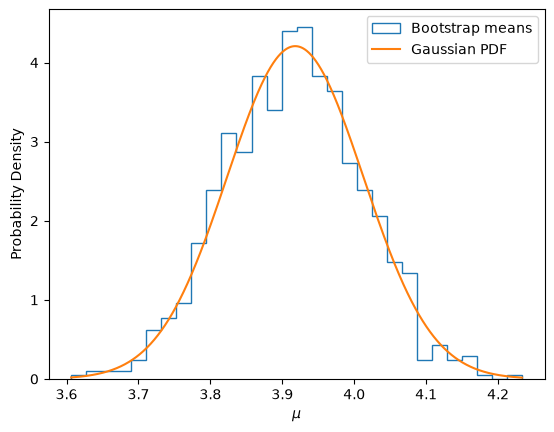

In [11]:
from scipy.stats import norm
import matplotlib.pyplot as plt

bootstrap_means = []

for i in range(1000):
    btsrp_data = bootstrap_sample(data)

    btsrp_x = btsrp_data[:, 0]
    btsrp_sigma = btsrp_data[:, 1]

    f_btsrp = lambda mu: ln_gaussian(mu, x=btsrp_x, sigma=btsrp_sigma)

    beta_btsrp = optimize.fmin(f_btsrp, mu0, disp=False)

    bootstrap_means.append(beta_btsrp[0])

bootstrap_means = np.array(bootstrap_means)

xgrid = np.linspace(bootstrap_means.min(), bootstrap_means.max(), 1000)

pdf = norm.pdf(xgrid, loc=mu, scale=sigma_mu)

plt.hist(bootstrap_means, bins=30, density=True,
         histtype='step', label='Bootstrap means')

plt.plot(xgrid, pdf, label='Gaussian PDF')

plt.xlabel(r'$\mu$')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

Yes, I think they agree.

<font color='blue'> 6.</font> Defining Laplace distribution first

In [12]:
def ln_laplace(mu, delta, x):
    return np.sum(np.log(2 * delta) + np.abs(x - mu) / delta)

In [13]:
f_laplace = lambda beta: ln_laplace(beta[0], beta[1], x)
beta0 = [mu, 1.0]
beta_laplace = optimize.fmin(f_laplace, beta0)
print(beta_laplace)

Optimization terminated successfully.
         Current function value: 156.788916
         Iterations: 39
         Function evaluations: 75
[4.08000019 0.88226924]


<font color='blue'> 7.</font> 

In [14]:
nll_gaussian = f_lnGaussian(beta_gaussian[0])
nll_laplace = f_laplace(beta_laplace)

print(nll_gaussian)
print(nll_laplace)

147.25786288730876
156.7889161765901


In [15]:
N = len(data)

k_gaussian = 1
k_laplace = 2

AIC_gaussian = 2*nll_gaussian + 2*k_gaussian + \
               2*k_gaussian*(k_gaussian+1)/(N-k_gaussian-1)

AIC_laplace = 2*nll_laplace + 2*k_laplace + \
              2*k_laplace*(k_laplace+1)/(N-k_laplace-1)

print("Gaussian AIC:", AIC_gaussian)
print("Laplace AIC:", AIC_laplace)

Gaussian AIC: 296.5565421011481
Laplace AIC: 317.7015436933864


Lower AIC indicates comparatively best fitted model which in this case is Gaussian.

<font color='blue'> 8.</font> 

In [16]:
bootstrap_laplace = []

for i in range(1000):
    btsrp_data = bootstrap_sample(data)
    btsrp_x = btsrp_data[:, 0]

    f_btsrp_laplace = lambda beta: ln_laplace(beta[0], beta[1], btsrp_x)

    beta_btsrp_laplace = optimize.fmin(
        f_btsrp_laplace, beta_laplace, disp=False
    )

    bootstrap_laplace.append(beta_btsrp_laplace)

bootstrap_laplace = np.array(bootstrap_laplace)

print(bootstrap_laplace.shape)

(1000, 2)


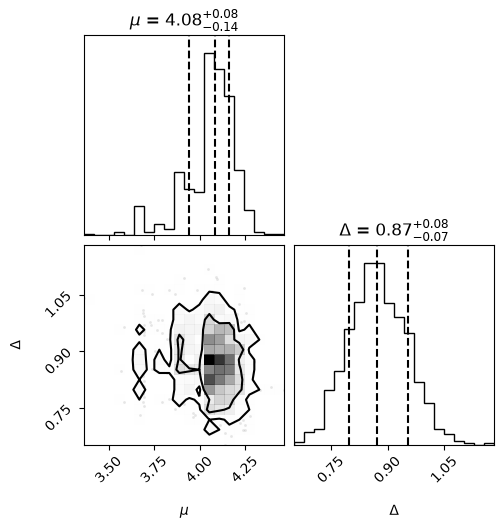

In [17]:
import corner

fig = corner.corner(
    bootstrap_laplace,
    labels=[r'$\mu$', r'$\Delta$'],
    show_titles=True,
    quantiles=[0.16, 0.5, 0.84],
    levels=[0.68, 0.95]
)

plt.show()

<font color='blue'> 9.</font> 

In [18]:
import numdifftools as nd
H = nd.Hessian(f_laplace)([beta_laplace[0], beta_laplace[1]])
sigma_laplace = np.diag(np.linalg.inv(H))**0.5

print(sigma_laplace)

[0.1092194  0.08822752]


In [19]:
bootstrap_laplace[:, 0]   # 1000 μ values
bootstrap_laplace[:, 1]   # 1000 Δ values

bootstrap_mu_width = np.std(bootstrap_laplace[:, 0])
bootstrap_delta_width = np.std(bootstrap_laplace[:, 1])

print(bootstrap_mu_width)
print(bootstrap_delta_width)

0.13173500430825888
0.07642356460997043


The fisher uncertainties $(\mu(0.1092194),~  \sigma(0.08822752))$ found above using Hessian matrix is comparable to the bootstrap width $(\mu(0.12548712018259311), ~ \sigma(0.07616697856214816))$.

<span style="color:green">NP: correct! </span>